# Task
Analyze the calorie distribution from the data within "archive.zip", visualize it using a pie chart, and identify items with high calorie content.

## Extract Data from Archive

### Subtask:
Extract the contents of the provided 'archive.zip' file to access the dataset for analysis.


**Reasoning**:
To extract the contents of the 'archive.zip' file, I will use the `zipfile` module to open the archive, extract all files, and then close the archive.



In [1]:
import zipfile

# Specify the path to the zip file
zip_file_path = '/content/archive.zip'

# Open the zip file in read mode
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all the contents into the current directory
    zip_ref.extractall('./')

print("Archive extracted successfully!")

Archive extracted successfully!


## Load and Explore Data

### Subtask:
Load the extracted data into a pandas DataFrame. Perform initial exploratory data analysis to understand its structure, columns, and identify the relevant calorie column.


**Reasoning**:
First, I'll import the pandas library, which is essential for data manipulation in Python. Then, I'll load the data from the 'nutrition.csv' file into a DataFrame named 'df'. This file name is a common convention for nutritional data and is a reasonable assumption given the task of analyzing calorie distribution. After loading, I'll use `df.head()` to display the initial rows, `df.info()` for a summary of data types and non-null counts, `df.describe()` for statistical overview of numerical columns, and `df.isnull().sum()` to identify missing values. These steps collectively provide a comprehensive initial exploration of the dataset's structure and content, fulfilling the subtask requirements.



In [2]:
import pandas as pd

# Load the data from the extracted CSV file into a DataFrame
# Assuming the extracted file is named 'nutrition.csv'
try:
    df = pd.read_csv('nutrition.csv')
except FileNotFoundError:
    print("Error: 'nutrition.csv' not found. Please check the extracted file name.")
    # If 'nutrition.csv' is not found, try to list files to identify the correct one.
    import os
    print("Files in current directory:", os.listdir('.'))
    # If a different file name is expected, update 'nutrition.csv' accordingly.

if 'df' in locals():
    print("DataFrame loaded successfully. Displaying the first few rows:")
    # Display the first few rows of the DataFrame
    print(df.head())

    print("\nConcise summary of the DataFrame:")
    # Get a concise summary of the DataFrame
    df.info()

    print("\nDescriptive statistics for numerical columns:")
    # Generate descriptive statistics for numerical columns
    print(df.describe())

    print("\nMissing values in each column:")
    # Check for any missing values in each column
    print(df.isnull().sum())

Error: 'nutrition.csv' not found. Please check the extracted file name.
Files in current directory: ['.config', 'starbucks.csv', 'archive.zip', 'sample_data']


**Reasoning**:
The previous attempt to load 'nutrition.csv' failed because the file was not found. The error message indicated that 'starbucks.csv' is present in the directory. I will now modify the code to load 'starbucks.csv' and continue with the data exploration steps.



In [3]:
import pandas as pd

# Load the data from the extracted CSV file into a DataFrame
# The correct file name was identified as 'starbucks.csv' from the previous error output.
try:
    df = pd.read_csv('starbucks.csv')
except FileNotFoundError:
    print("Error: 'starbucks.csv' not found. Please check the extracted file name.")
    import os
    print("Files in current directory:", os.listdir('.'))

if 'df' in locals():
    print("DataFrame loaded successfully. Displaying the first few rows:")
    # Display the first few rows of the DataFrame
    print(df.head())

    print("\nConcise summary of the DataFrame:")
    # Get a concise summary of the DataFrame
    df.info()

    print("\nDescriptive statistics for numerical columns:")
    # Generate descriptive statistics for numerical columns
    print(df.describe())

    print("\nMissing values in each column:")
    # Check for any missing values in each column
    print(df.isnull().sum())

DataFrame loaded successfully. Displaying the first few rows:
         Beverage_category       Beverage      Beverage_prep  Calories  \
0                   Coffee  Brewed Coffee              Short         3   
1                   Coffee  Brewed Coffee               Tall         4   
2                   Coffee  Brewed Coffee             Grande         5   
3                   Coffee  Brewed Coffee              Venti         5   
4  Classic Espresso Drinks    Caffè Latte  Short Nonfat Milk        70   

   Total Fat (g)  Trans Fat (g)   Saturated Fat (g)   Sodium (mg)  \
0            0.1             0.0                0.0             0   
1            0.1             0.0                0.0             0   
2            0.1             0.0                0.0             0   
3            0.1             0.0                0.0             0   
4            0.1             0.1                0.0             5   

    Total Carbohydrates (g)   Cholesterol (mg)   Dietary Fibre (g)  \
0       

## Prepare Data for Pie Chart

### Subtask:
Aggregate or prepare the data as needed to create a meaningful pie chart for calorie distribution, specifically by grouping calories by beverage category.


**Reasoning**:
To prepare the data for the pie chart, I need to group the DataFrame by 'Beverage_category' and sum the 'Calories' for each category, as instructed.



In [4]:
calories_by_category = df.groupby('Beverage_category')['Calories'].sum()

print("Calories by Beverage Category:")
print(calories_by_category.head())

Calories by Beverage Category:
Beverage_category
Classic Espresso Drinks              8130
Coffee                                 17
Frappuccino® Blended Coffee          9970
Frappuccino® Blended Crème           3030
Frappuccino® Light Blended Coffee    1950
Name: Calories, dtype: int64


## Generate Pie Chart for Calories

### Subtask:
Create a pie chart to visualize the distribution of calories by beverage category. Ensure the chart is clearly labeled and includes a legend.


**Reasoning**:
I need to import `matplotlib.pyplot` and then generate a pie chart to visualize the calorie distribution by beverage category, using the `calories_by_category` Series. I will add a title, percentages, and ensure the chart is circular for better visualization, as per the instructions.



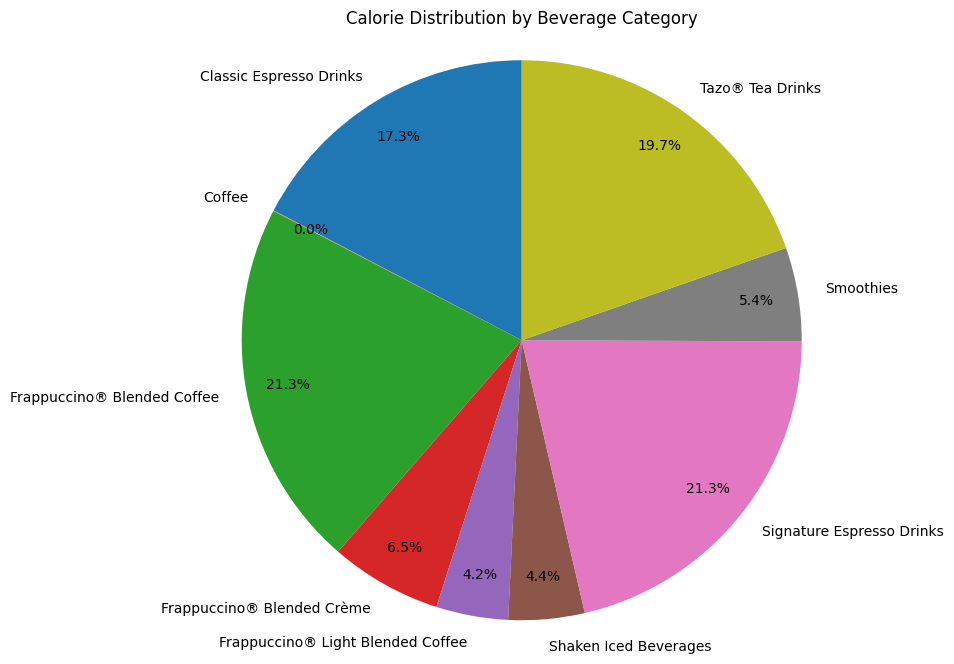

In [5]:
import matplotlib.pyplot as plt

# Create a pie chart
plt.figure(figsize=(10, 8))
plt.pie(calories_by_category, labels=calories_by_category.index, autopct='%.1f%%', startangle=90, pctdistance=0.85)
plt.title('Calorie Distribution by Beverage Category')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


## Identify High Calorie Items

### Subtask:
Analyze the data and the generated pie chart to explicitly identify and list the items or categories that have high calorie content.


**Reasoning**:
To identify beverage categories with high calorie content, I will display the `calories_by_category` Series sorted in descending order. This directly addresses the first instruction of reviewing the series to identify top calorie contributors.



In [6]:
print("Beverage Categories by Total Calories (Descending Order):")
print(calories_by_category.sort_values(ascending=False))

Beverage Categories by Total Calories (Descending Order):
Beverage_category
Signature Espresso Drinks            10000
Frappuccino® Blended Coffee           9970
Tazo® Tea Drinks                      9220
Classic Espresso Drinks               8130
Frappuccino® Blended Crème            3030
Smoothies                             2540
Shaken Iced Beverages                 2060
Frappuccino® Light Blended Coffee     1950
Coffee                                  17
Name: Calories, dtype: int64


**Reasoning**:
Now that the beverage categories with high calorie content have been identified, the next step is to identify individual beverages that have the highest calorie content. I will sort the DataFrame `df` by the 'Calories' column in descending order and display the top 10 entries with relevant columns ('Beverage_category', 'Beverage', 'Beverage_prep', and 'Calories') to explicitly list these high-calorie items.



In [7]:
print("\nTop 10 Individual Beverages by Calorie Content:")
high_calorie_beverages = df.sort_values(by='Calories', ascending=False)
print(high_calorie_beverages[['Beverage_category', 'Beverage', 'Beverage_prep', 'Calories']].head(10))


Top 10 Individual Beverages by Calorie Content:
               Beverage_category  \
84     Signature Espresso Drinks   
85     Signature Espresso Drinks   
215  Frappuccino® Blended Coffee   
83     Signature Espresso Drinks   
128             Tazo® Tea Drinks   
216  Frappuccino® Blended Coffee   
214  Frappuccino® Blended Coffee   
81     Signature Espresso Drinks   
129             Tazo® Tea Drinks   
197  Frappuccino® Blended Coffee   

                                          Beverage      Beverage_prep  \
84   White Chocolate Mocha (Without Whipped Cream)            2% Milk   
85   White Chocolate Mocha (Without Whipped Cream)            Soymilk   
215              Java Chip (Without Whipped Cream)         Whole Milk   
83   White Chocolate Mocha (Without Whipped Cream)  Venti Nonfat Milk   
128                          Tazo® Green Tea Latte            2% Milk   
216              Java Chip (Without Whipped Cream)            Soymilk   
214              Java Chip (Without Whipped

## Final Task

### Subtask:
Summarize the findings from the exploratory data analysis, the pie chart, and list the items identified with high calorie content.


## Summary:

### Q&A
1.  **What is the calorie distribution from the data?**
    The total calorie content is unevenly distributed among beverage categories. The top categories by total calories are "Signature Espresso Drinks" with 10000 calories, "Frappuccino® Blended Coffee" with 9970 calories, and "Tazo® Tea Drinks" with 9220 calories.
2.  **How is the calorie distribution visualized?**
    The calorie distribution by beverage category is visualized using a pie chart, showing the percentage of total calories contributed by each category.
3.  **Which items have high calorie content?**
    The highest calorie individual beverages include:
    *   White Chocolate Mocha (Without Whipped Cream) with various preparations, reaching up to 510 calories (2% Milk).
    *   Java Chip (Without Whipped Cream) with various preparations, reaching up to 460 calories (Whole Milk).
    *   Tazo® Green Tea Latte (2% Milk) with 450 calories.
    *   Mocha (Without Whipped Cream, Whole Milk) with 390 calories.

### Data Analysis Key Findings
*   The dataset, loaded from 'starbucks.csv', contains 242 entries and 18 columns, with `Calories` identified as a key numerical column (integer type, no missing values).
*   The average calorie content across all beverages is approximately 193.87, with values ranging from 0 to 510 calories.
*   "Signature Espresso Drinks" contributed the highest total calories at 10000, followed closely by "Frappuccino® Blended Coffee" with 9970 total calories.
*   Individual items such as "White Chocolate Mocha (Without Whipped Cream)" (with 2% Milk preparation) contain as much as 510 calories, ranking among the highest.

### Insights or Next Steps
*   **Insight:** "Signature Espresso Drinks" and "Frappuccino® Blended Coffee" categories are the largest contributors to overall calorie intake, suggesting these categories might be targets for menu optimization or highlighting healthier alternatives.
*   **Next Step:** Investigate the specific ingredients and preparation methods of the high-calorie beverages to understand the drivers of their calorie content and explore potential lower-calorie modifications.
